In [163]:
# Basic imports Andrej do every time.
import math
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

In [164]:
class Value:
    """The value object that refers to micrograd."""
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self.grad = 0 # When initializing, we assume all variables have no impact on output.
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        """wrapper prints a value with a nicer looking."""
        # if self._op == '':
        #     return f"Value(data={self.data}, children={self._prev})"
        # else:
        #     return f"Value(data={self.data}, children={self._prev}, _op={self._op})"
        return f"Value(data = {self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other ** -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float type."

        out = Value(self.data ** other, (self, ), f'**{other}')
        def _backward():
            self.grad += out.grad * other * (self.data ** (other - 1))
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - out.data ** 2) * out.grad
        # out._backward = _backward() ->TypeError: 'NoneType' object is not callable
        out._backward = _backward
        return out

    def backward(self):
    # Topological Sort
        topo = []
        visited = set()

        def build_topo(v: Value) -> None:
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

# Cut from Andrej Karpathy, collected by LLM.

from graphviz import Digraph
from typing import Set, Tuple, Any

def trace(root: Any) -> Tuple[Set[Any], Set[Tuple[Any, Any]]]:
    """
    从根节点出发，递归遍历整个计算图，收集所有节点和边。
    Args:
        root: 计算图的根节点（输出 Value 对象）。
    Returns:
        nodes: 图中所有节点的集合。
        edges: 图中所有有向边的集合，每条边为 (子节点, 父节点)。
    """
    nodes: Set[Any] = set()
    edges: Set[Tuple[Any, Any]] = set()

    def build(v: Any) -> None:
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root: Any) -> Digraph:
    """
    将计算图渲染为 Graphviz 的有向图对象（从左到右布局）。
    每个 Value 节点显示：标签名 | data 值 | grad 梯度。
    若节点由运算产生，则额外绘制一个运算节点（+、* 等）连接到该 Value 节点。
    Args:
        root: 计算图的根节点（最终输出 Value 对象）。
    Returns:
        dot: 一个 graphviz.Digraph 对象，可直接在 Jupyter 中渲染，
             或调用 .render() 保存为 svg / png 文件。
    """
    dot = Digraph(
        format='svg',
        graph_attr={'rankdir': 'LR'},  # LR = Left to Right，从左到右
        node_attr={'fontname': 'Helvetica'},
    )

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # 为每个 Value 对象画一个 record 形状的节点
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record',
        )
        # 如果该节点是运算的结果，再画一个运算节点并连到 Value 节点
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # 子节点 → 父节点的运算节点
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

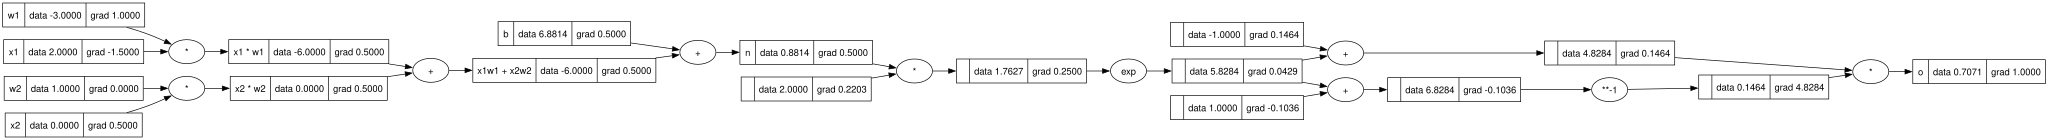

In [165]:
# example.
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# neural bias b
b  = Value(6.881373587019, label='b')

# multiply
x1w1 = x1 * w1
x1w1.label = 'x1 * w1'
x2w2 = x2 * w2
x2w2.label = 'x2 * w2'

# \sum w_ix_i + b
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b
n.label = 'n'
esquarex = (n * 2).exp()
o = (esquarex - 1) / (esquarex + 1)
o.label = 'o'

o.backward()
draw_dot(o)

In [166]:
x1 = torch.Tensor([2.0]).double();               x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();               x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();              w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();               w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print("---")

print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


### Explain
implementing neural nets

In [167]:
class Neuron:
    def __init__(self, nin): # nin stands for Numbers of INputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b =  Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return [self.b] + self.w

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [168]:
n = MLP(3, [4, 4, 1])
x_samples = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
y_expected = [1.0, -1.0, -1.0, 1.0]

y_predicted = [n(x) for x in x_samples]
loss = sum((yout - ygt) ** 2 for yout, ygt in zip(y_predicted, y_expected))
for p in n.parameters():
    p.data += -0.01 * p.data
loss.backward()
print("---panel---")
print("first_loss:  ", loss)
print("predicted:   ", y_predicted)
# print("MLP parameters: \n", n.parameters())
# draw_dot(loss)


---panel---
first_loss:   Value(data = 6.886444260615133)
predicted:    [Value(data = 0.8777031678067435), Value(data = 0.8295142188393664), Value(data = 0.872727190392447), Value(data = 0.8686290028962904)]


In [178]:
print("---training---")
for k in range(20):

    # forward pass
    y_predicted = [n(x) for x in x_samples]
    loss = sum((yout - ygt) ** 2 for yout, ygt in zip(y_predicted, y_expected))

    # set grad to zero
    # three common mistakes in neural networks, number 3: forget to use zerograd() before backprop.
    for p in n.parameters():
        p.data = 0.0

    # backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

print("---panel---")
print("final_loss:  ", loss)
print("predicted:   ", y_predicted)

---training---
0 1.4488529261465374e-05
1 1.4488333050494553e-05
2 1.4488136844833377e-05
3 1.448794064448085e-05
4 1.448774444943777e-05
5 1.4487548259703213e-05
6 1.4487352075277097e-05
7 1.4487155896159341e-05
8 1.4486959722349831e-05
9 1.4486763553847677e-05
10 1.4486567390653638e-05
11 1.448637123276676e-05
12 1.4486175080187027e-05
13 1.4485978932915132e-05
14 1.4485782790949346e-05
15 1.4485586654289586e-05
16 1.4485390522937424e-05
17 1.448519439689028e-05
18 1.4484998276149765e-05
19 1.4484802160714916e-05
---panel---
final_loss:   Value(data = 1.4484802160714916e-05)
predicted:    [Value(data = 0.9998506000112561), Value(data = -0.9999995809059894), Value(data = -0.9999919868321073), Value(data = 0.9961970514837065)]
